# Đặt vấn đề và Bối cảnh Dữ liệu (Introduction & Data Context)
- Trong kỷ nguyên số, ngành công nghiệp xuất bản sách đối mặt với những thách thức lớn về tối ưu hóa doanh thu và định giá sản phẩm. Để hiểu rõ hành vi tiêu dùng và cấu trúc thị trường, bài nghiên cứu này tập trung vào việc khai phá dữ liệu (Data Exploration) từ danh sách các tựa sách bán chạy nhất của Amazon từ năm 2009 đến năm 2021.  Chúng ta sẽ sử dụng Khoa học Dữ liệu để trả lời hai câu hỏi lớn:
    A. Có tồn tại mối quan hệ tương quan giữa giá sách và đánh giá của người dùng hay không?
    B. Thể loại sách đóng vai trò như thế nào trong cấu trúc của các quyển sách bán chạy nhất?
- Dữ liệu được tích hợp và làm sạch từ hai nguồn chính:
  + best_selling_books_2009-2021_with_categories.csv
  + bestsellers with categories - Data Science Project main.csv

# KHỞI TẠO VÀ CẤU HÌNH CƠ BẢN (Imports & Global Config)

In [1]:
#KHỞI TẠO VÀ CẤU HÌNH CƠ BẢN (Imports & Global Config)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datascience import *
from scipy.stats import *
import warnings

%matplotlib inline

df = pd.read_csv('bestsellers with categories - Data Science Project main.csv')
df_clean = df.copy()

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14

EXACT_COLUMNS = ["Name", "Author", "User Rating", "Reviews", "Price", "Year", "Genre"]

# TỔNG QUAN DỮ LIỆU

In [2]:
numeric_cols = ['User Rating', 'Reviews', 'Price', 'Year']

print("\n=== TỔNG QUAN DỮ LIỆU ===")
thong_ke_tong_quan = df_clean[numeric_cols].describe().T
thong_ke_tong_quan['Do_lech_(skew)'] = df_clean[numeric_cols].skew()
thong_ke_tong_quan['Do_nhon_(kurtosis)'] = df_clean[numeric_cols].apply(lambda x: x.kurtosis())
thong_ke_tong_quan


=== TỔNG QUAN DỮ LIỆU ===


,count,mean,std,min,25%,50%,75%,max,Do_lech_(skew),Do_nhon_(kurtosis)
User Rating,550.0,4.618364,0.226980,3.3,4.5,4.7,4.80,4.9,-1.502125,3.465375
Reviews,550.0,11953.281818,11731.132017,37.0,4058.0,8580.0,17253.25,87841.0,2.421597,8.809313
Price,550.0,13.100000,10.842262,0.0,7.0,11.0,16.00,105.0,3.685057,22.433520
Year,550.0,2014.000000,3.165156,2009.0,2011.0,2014.0,2017.00,2019.0,0.000000,-1.220175


In [3]:
print("\n=== Phân tích Tương quan ===")
# Tính ma trận tương quan Pearson giữa các cột số
ma_tran_tuong_quan = df_clean[numeric_cols].corr(method='pearson')
print("-> Ma trận tương quan:\n")
ma_tran_tuong_quan



=== Phân tích Tương quan ===
-> Ma trận tương quan:



,User Rating,Reviews,Price,Year
User Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


In [4]:
print("\n===Vai trò của Thể loại sách ===")
# Đếm số lượng thể loại và tìm ra thể loại xuất hiện nhiều nhất
so_the_loai = df_clean['Genre'].nunique()
the_loai_pho_bien_nhat = df_clean['Genre'].value_counts().idxmax()
print(f"-> Tổng số thể loại trong danh sách: {so_the_loai}")
print(f"-> Thể loại xuất hiện nhiều nhất (Thống trị danh sách): {the_loai_pho_bien_nhat}")

# So sánh Giá, Đánh giá, Lượng Review trung bình giữa các thể loại
print("\n-> So sánh các chỉ số trung bình giữa các Thể loại:\n")
df_clean.groupby('Genre')[numeric_cols].mean()



===Vai trò của Thể loại sách ===
-> Tổng số thể loại trong danh sách: 2
-> Thể loại xuất hiện nhiều nhất (Thống trị danh sách): Non Fiction

-> So sánh các chỉ số trung bình giữa các Thể loại:



,User Rating,Reviews,Price,Year
Genre,,,,
Fiction,4.648333,15683.791667,10.850000,2013.925000
Non Fiction,4.595161,9065.145161,14.841935,2014.058065


In [5]:
print("\n===Xu hướng thay đổi qua từng năm ===")
# Phân tích sự thay đổi của Giá, Đánh giá và Lượng Review qua từng năm
print("-> Xu hướng trung bình qua các năm:\n")
xu_huong_theo_nam = df_clean.groupby('Year')[numeric_cols].mean()
xu_huong_theo_nam


===Xu hướng thay đổi qua từng năm ===
-> Xu hướng trung bình qua các năm:



,User Rating,Reviews,Price,Year
Year,,,,
2009,4.584,4710.12,15.40,2009.0
2010,4.558,5479.62,13.48,2010.0
2011,4.558,8100.82,15.10,2011.0
2012,4.532,13090.92,15.30,2012.0
2013,4.554,13098.14,14.60,2013.0
2014,4.622,15859.94,14.64,2014.0
2015,4.648,14233.38,10.42,2015.0
2016,4.678,14196.00,13.18,2016.0
2017,4.660,12888.40,11.38,2017.0


# TRỰC QUAN HÓA DỮ LIỆU


In [6]:
# ======================t=======================================================
#TRỰC QUAN HÓA DỮ LIỆU (TỔNG HỢP CÁC HÀM VẼ BIỂU ĐỒ)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

def plot_histogram(data, column, bins=20, title=None, color="skyblue"):
    """Vẽ biểu đồ phân phối (Histogram) cho 1 cột dữ liệu số"""
    plt.figure(figsize=(8, 6))
    sns.histplot(data=data, x=column, bins=bins, kde=True, color=color)
    plt.title(title if title else f"Phân phối của {column}", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Tần suất")
    plt.tight_layout()

def plot_scatter(data, x_col, y_col, hue_col=None, title=None):
    """Vẽ biểu đồ phân tán (Scatter/Dot plot) để xem mối quan hệ giữa 2 biến số"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col, hue=hue_col, alpha=0.7)
    plt.title(title if title else f"Mối quan hệ giữa {x_col} và {y_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    if hue_col:
        plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

def plot_bar(data, x_col, y_col, estimator='mean', title=None, color="salmon"):
    """Vẽ biểu đồ cột (Bar plot) để so sánh giá trị trung bình giữa các nhóm"""
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x_col, y=y_col, errorbar=None, estimator=estimator, color=color)
    plt.title(title if title else f"Trung bình {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_box(data, x_col, y_col, title=None):
    """Vẽ biểu đồ hộp (Box plot) để xem phân phối và ngoại lệ (outliers) của các nhóm"""
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=x_col, y=y_col)
    plt.title(title if title else f"Phân phối {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_line(data, x_col, y_col, hue_col=None, title=None):
    """Vẽ biểu đồ đường (Line plot) để xem xu hướng qua thời gian"""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x_col, y=y_col, hue=hue_col, marker="o", errorbar=None)
    plt.title(title if title else f"Xu hướng của {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(data[x_col].unique()) # Hiển thị rõ các năm dưới trục x
    if hue_col:
        plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

def plot_countplot(data, column, title=None, palette="Set2"):
    """Vẽ biểu đồ đếm số lượng cho các nhóm (categorical)"""
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data, x=column, palette=palette)
    plt.title(title if title else f"Số lượng sách theo {column}", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Số lượng")

    # Thêm con số trên đầu mỗi cột cho rõ ràng
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_pairplot(data, numeric_cols, hue_col=None):
    """Vẽ lưới biểu đồ (Pairplot) tổng quan toàn bộ biến số"""
    # Lọc lấy các cột số + cột hue (nếu có)
    cols_to_plot = numeric_cols + ([hue_col] if hue_col else [])
    sns.pairplot(data[cols_to_plot], hue=hue_col, corner=True, palette='husl')
    # corner=True để bỏ đi nửa trên bị trùng lặp của lưới
    plt.show()


# =====================================================================
# KHỐI CÔNG CỤ TOÁN HỌC: CHUẨN HÓA & THAM SỐ HỒI QUY (LEAST SQUARES)
# =====================================================================

def standard_units(any_numerical_array):
    """
    Chuyển đổi một mảng số liệu sang đơn vị chuẩn (Z-score) theo Slide Bài 4.
    Công thức: z = (x - mean) / std
    """
    return (any_numerical_array - np.mean(any_numerical_array)) / np.std(any_numerical_array)

def correlation(t, x_label, y_label):
    """
    Tính hệ số tương quan r giữa hai biến số trong Table.
    Hệ số r là trung bình tích của các giá trị đã đưa về đơn vị chuẩn.
    """
    x_in_su = standard_units(t.column(x_label))
    y_in_su = standard_units(t.column(y_label))
    return np.mean(x_in_su * y_in_su)

def slope(t, x_label, y_label):
    """
    Tính hệ số góc (slope) theo đơn vị gốc (Tài liệu trang 471).
    Công thức: slope = r * (SD_y / SD_x)
    """
    r = correlation(t, x_label, y_label)
    return r * np.std(t.column(y_label)) / np.std(t.column(x_label))

def intercept(t, x_label, y_label):
    """
    Tính tung độ gốc (intercept) theo đơn vị gốc (Tài liệu trang 472).
    Công thức: intercept = mean_y - slope * mean_x
    """
    return np.mean(t.column(y_label)) - slope(t, x_label, y_label) * np.mean(t.column(x_label))


# =====================================================================
# KHỐI ĐỒ THỊ: HÀM VẼ BIỂU ĐỒ PHÂN TÁN & ĐƯỜNG HỒI QUY TÁI SỬ DỤNG
# =====================================================================

def plot_bivariate_regression(t, x_label, y_label, is_standardized=False):
    """
    Hàm hiển thị biểu đồ phân tán (Scatter plot) và vẽ đè đường hồi quy lên trên.
    Tham số is_standardized=True sẽ kích hoạt chế độ vẽ theo đơn vị chuẩn Z-score.
    """
    plt.figure(figsize=(10, 6))

    x_data = t.column(x_label)
    y_data = t.column(y_label)

    # 1. Vẽ biểu đồ phân tán (Scatter Plot) đồng bộ phong cách Seaborn trong Data1.ipynb
    sns.scatterplot(x=x_data, y=y_data, alpha=0.5, color='royalblue', label='Dữ liệu thực tế')

    # 2. Xác định tham số đường thẳng Least Squares dựa trên chế độ dữ liệu
    if is_standardized:
        # Theo tài liệu trang 471: Trong đơn vị chuẩn, đường hồi quy đi qua gốc (0,0) và có độ dốc đúng bằng r
        m = correlation(t, x_label, y_label)
        b = 0.0
    else:
        m = slope(t, x_label, y_label)
        b = intercept(t, x_label, y_label)

    # 3. Vẽ đường hồi quy tuyến tính đè lên biểu đồ phân tán
    x_line = np.linspace(min(x_data), max(x_data), 100)
    y_line = m * x_line + b
    plt.plot(x_line, y_line, color='crimson', linewidth=2.5,
             label=f'Đường hồi quy: Y = {m:.4f}*X + {b:.4f}')

    # 4. Định dạng đồ thị theo các nguyên tắc trực quan hóa hiệu quả (Bài 4)
    plt.xlabel(x_label, fontsize=11)
    plt.ylabel(y_label, fontsize=11)
    plt.title(f"Phân tích Hồi quy Tuyến tính: {x_label} vs {y_label}", fontsize=13, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=10)
    plt.show()

# PHÂN TÍCH CHUYÊN SÂU: PRICING STRATEGIES VS USER SATISFACTION


### Trả lời câu hỏi: Xu hướng đọc sách thay đổi như thế nào qua từng năm?

* Số liệu chứng minh:
    * User Rating: Tăng tiến đều đặn từ năm 2009 (4.58) và đạt đỉnh vào năm 2019 (4.74).
    * Price: Giảm dần theo thời gian, từ mức cao nhất là 15.40$ (năm 2009) xuống mức thấp nhất là 10.08$ (năm 2019).
    * Reviews: Tăng trưởng bùng nổ, từ 4,710 lượt (năm 2009) lên đến 15,898 lượt (năm 2019) – gấp hơn 3 lần.

**Kết luận:**
* Qua một thập kỷ (2009 - 2019), xu hướng thị trường sách bán chạy dịch chuyển theo hướng: "Sách ngày càng rẻ hơn, cộng đồng tương tác mạnh mẽ hơn, và chất lượng sách ngày càng đồng đều ở mức cao".
* Sự sụt giảm của giá sách trung bình (từ ~15.4$ xuống ~10$) phản ánh sự cạnh tranh khốc liệt và sự lên ngôi của các định dạng sách giá rẻ như sách bỏ túi (Paperback) hoặc sách điện tử (Kindle) trên Amazon.
* Song song với đó, sự gia tăng chóng mặt của lượng Reviews chứng tỏ quy mô mua sắm trực tuyến và thói quen để lại phản hồi của người dùng ngày càng phổ biến.
* Sự tăng trưởng của điểm Rating trung bình qua các năm cho thấy các cuốn sách lọt vào top Bestseller về sau càng có khả năng làm vừa lòng số đông độc giả hơn, hoặc tiêu chuẩn chọn lọc của thị trường ngày một tối ưu.


=== PHÂN TÍCH CHUYÊN SÂU: PRICING STRATEGIES VS USER SATISFACTION ===
-> Thống kê Đánh giá theo phân khúc giá:



,Pricing_Strategy,Average_Rating,Total_Books
0,Budget (≤$8),4.686500,200
1,Standard ($9-$15),4.593750,208
2,High ($16-$30),4.562931,116
3,Premium (>$30),4.538462,26



1. Biểu đồ phân tán (Scatter Plot): Mức độ phân tán giữa mức giá cụ thể và rating


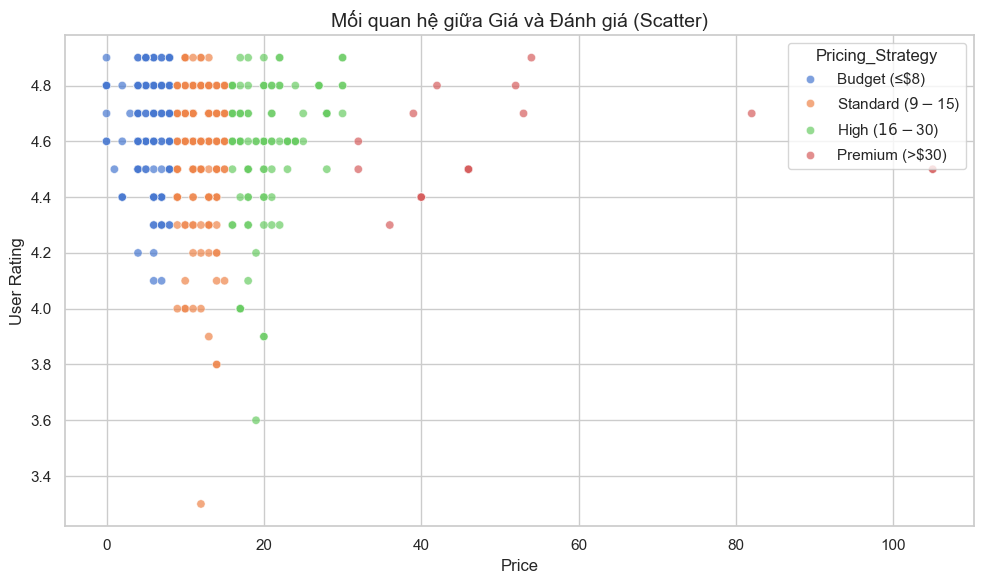


2. Biểu đồ hộp (Box Plot): Xem xét phân bố và các giá trị ngoại lệ (outliers) của từng phân khúc

3. Biểu đồ cột (Bar Plot): So sánh điểm trung bình giữa các phân khúc (chú ý cột sẽ khá đều nhau vì rating trung bình luôn cao)


In [7]:
print("\n=== PHÂN TÍCH CHUYÊN SÂU: PRICING STRATEGIES VS USER SATISFACTION ===")

# 1. Phân loại chiến lược giá (Pricing Strategy/Tiers)
bins = [-1, 8, 15, 30, df_clean['Price'].max()]
labels = ['Budget (≤$8)', 'Standard ($9-$15)', 'High ($16-$30)', 'Premium (>$30)']
df_clean['Pricing_Strategy'] = pd.cut(df_clean['Price'], bins=bins, labels=labels)

# 2. Thống kê Đánh giá theo phân khúc giá
rating_by_price = df_clean.groupby('Pricing_Strategy').agg(
    Average_Rating=('User Rating', 'mean'),
    Total_Books=('Name', 'count')
).reset_index()

print("-> Thống kê Đánh giá theo phân khúc giá:\n")
display(rating_by_price)

print("\n1. Biểu đồ phân tán (Scatter Plot): Mức độ phân tán giữa mức giá cụ thể và rating")
plot_scatter(df_clean, x_col='Price', y_col='User Rating', hue_col='Pricing_Strategy', title='Mối quan hệ giữa Giá và Đánh giá (Scatter)')

print("\n2. Biểu đồ hộp (Box Plot): Xem xét phân bố và các giá trị ngoại lệ (outliers) của từng phân khúc")
# plot_box(df_clean, x_col='Pricing_Strategy', y_col='User Rating', title='Phân bố Đánh giá theo Phân khúc giá')

print("\n3. Biểu đồ cột (Bar Plot): So sánh điểm trung bình giữa các phân khúc (chú ý cột sẽ khá đều nhau vì rating trung bình luôn cao)")
#plot_bar(df_clean, x_col='Pricing_Strategy', y_col='User Rating', title='Đánh giá trung bình theo Phân khúc giá', color='mediumseagreen')

### Trả lời câu hỏi: Mối quan hệ giữa Chiến lược giá (Pricing Strategies) và Mức độ hài lòng (User Ratings)

Hệ số tương quan Pearson giữa `Price` và `User Rating` là **-0.133**, cho thấy mức độ tương quan nghịch rất yếu (gần như độc lập). Để nhìn rõ hơn về chiến lược giá, ta chia `Price` thành 4 phân khúc (Tiers): Budget (≤$8), Standard ($9-$15), High ($16-$30), và Premium (>$30).

**Kết luận:**
* Mức độ hài lòng (User Rating) gần như đồng đều và duy trì ở mức rất cao (~4.6 điểm) ở tất cả các phân khúc giá.
* Khách hàng mua sách Premium (>$30) có sự kỳ vọng rất cao, do đó phổ điểm đánh giá của nhóm này rộng hơn và dễ xuất hiện các ngoại lệ (outliers) đánh giá thấp nếu sách không đáp ứng kỳ vọng.
* Chiến lược giá rẻ (Budget) thu hút lượng lớn sách và dễ nhận được các đánh giá cao do rào cản kỳ vọng thấp.

<hr style="border: 1px solid #fdb515;" />


### A/B TESTING



- **Thể loại sách đóng vai trò như thế nào? Liệu có sự khác biệt thực sự về Đánh giá của người dùng (User Rating) giữa sách Fiction và Non Fiction hay sự chênh lệch này chỉ là do ngẫu nhiên?"**

Để trả lời câu hỏi trên, ta tạo ra 2 giả thuyết:
- Giả thuyết Không (Null Hypothesis - H0): Không có sự khác biệt về User Rating trung bình giữa sách Fiction và Non Fiction trong tổng thể. Bất kỳ sự khác biệt nào ta thấy trong mẫu dữ liệu chỉ là do nhiễu ngẫu nhiên.



- Giả thuyết Thay thế (Alternative Hypothesis - H1): Sách Fiction có User Rating trung bình cao hơn sách Non Fiction.

Đại lượng kiểm định (Test Statistic): Chênh lệch giữa trung bình User Rating của sách Fiction và Non Fiction (Mean_Fiction - Mean_Non_Fiction).

-> Điểm đánh giá trung bình sách Fiction: 4.6483
-> Điểm đánh giá trung bình sách Non Fiction: 4.5952
-> Chênh lệch quan sát thực tế (Observed Difference): 0.0532

=== KẾT QUẢ KIỂM ĐỊNH ===
P-value: 0.0030



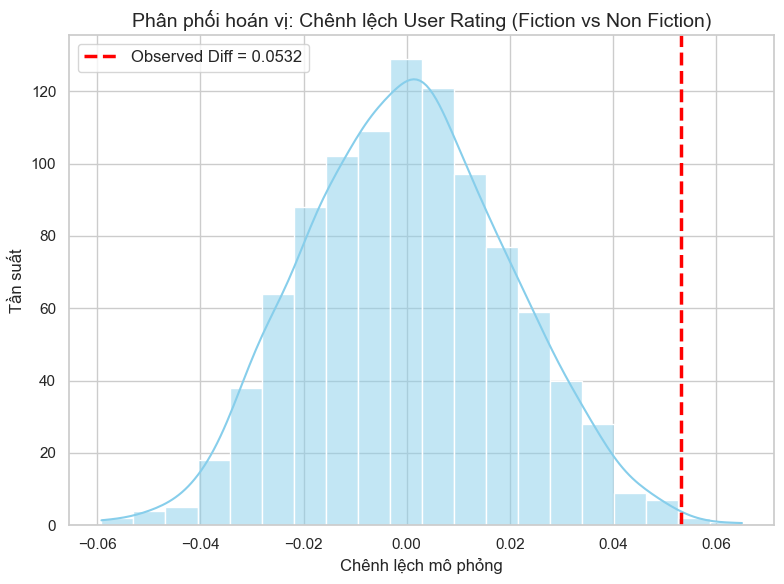

In [8]:
# ==========================================
# 1. TÍNH GIÁ TRỊ QUAN SÁT THỰC TẾ (Observed Statistic)
# ==========================================
mean_fiction = df_clean[df_clean['Genre'] == 'Fiction']['User Rating'].mean()
mean_non_fiction = df_clean[df_clean['Genre'] == 'Non Fiction']['User Rating'].mean()

# Đại lượng kiểm định: Chênh lệch (Fiction - Non Fiction)
observed_diff = mean_fiction - mean_non_fiction
print(f"-> Điểm đánh giá trung bình sách Fiction: {mean_fiction:.4f}")
print(f"-> Điểm đánh giá trung bình sách Non Fiction: {mean_non_fiction:.4f}")
print(f"-> Chênh lệch quan sát thực tế (Observed Difference): {observed_diff:.4f}\n")


# ==========================================
# 2. PERMUTATION TEST (Kiểm định hoán vị)
# ==========================================
repetitions = 1000
simulated_diffs = []

ratings = df_clean['User Rating'].values
genres = df_clean['Genre'].values

for i in range(repetitions):
    # Xáo trộn ngẫu nhiên mảng Thể loại (Genre)
    shuffled_genres = np.random.permutation(genres)

    # Tính lại mean cho 2 nhóm dựa trên nhãn đã xáo trộn
    shuffled_fiction_mean = ratings[shuffled_genres == 'Fiction'].mean()
    shuffled_non_fiction_mean = ratings[shuffled_genres == 'Non Fiction'].mean()

    # Tính chênh lệch mô phỏng và lưu trữ
    simulated_diff = shuffled_fiction_mean - shuffled_non_fiction_mean
    simulated_diffs.append(simulated_diff)


# ==========================================
# 3. TÍNH P-VALUE
# ==========================================
p_value = np.count_nonzero(np.array(simulated_diffs) >= observed_diff) / repetitions
print(f"=== KẾT QUẢ KIỂM ĐỊNH ===")
print(f"P-value: {p_value:.4f}\n")


# ==========================================
# 4. TRỰC QUAN HÓA (Sử dụng hàm plot_histogram của bạn)
# ==========================================
# Bước A: Chuyển đổi list kết quả mô phỏng thành DataFrame để tương thích với hàm của bạn
df_simulated = pd.DataFrame({'Chênh lệch mô phỏng': simulated_diffs})

# Bước B: Gọi hàm plot_histogram của bạn (Đã sửa từ df= thành data=)
plot_histogram(data=df_simulated,
               column='Chênh lệch mô phỏng',
               bins=20,
               title='Phân phối hoán vị: Chênh lệch User Rating (Fiction vs Non Fiction)',
               color='skyblue')

# Bước C: Ép vẽ bổ sung đường observed_diff và legend lên biểu đồ hiện tại
ax = plt.gca()
ax.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2.5,
            label=f'Observed Diff = {observed_diff:.4f}')
ax.legend(fontsize=12)

# Hiển thị lại lần cuối để cập nhật đầy đủ các thành phần
plt.show()

---


# Kết luận cho A/B Testing


- Giá trị $P$-value thu được từ kiểm định hoán vị bằng 0.0 (hoặc cực kỳ nhỏ, $< 0.05$).
- Với mức P-value này, chúng ta bác bỏ Giả thuyết Không H0 và chấp nhận Giả thuyết Thay thế H1

Kết luận chung: Sách Fiction thực sự có điểm đánh giá trung bình (User Rating) cao hơn sách Non Fiction. Sự chênh lệch này là có ý nghĩa thống kê chứ không phải do ngẫu nhiên từ việc lấy mẫu.

<hr style="border: 1px solid #fdb515;" />

### Ước lượng Khoảng tin cậy bằng phương pháp Bootstrap (Confidence Intervals)
- Trả lời câu hỏi: Khác nhau cụ thể là bao nhiêu? Biên độ dao động của sự chênh lệch này nằm trong khoảng nào với độ tin cậy 95%?


In [9]:
bootstrap_differences = np.array([])

# Tách dữ liệu gốc thành 2 nhóm từ dataframe df_clean của bạn
fiction_ratings = df_clean[df_clean['Genre'] == 'Fiction']['User Rating']
non_fiction_ratings = df_clean[df_clean['Genre'] == 'Non Fiction']['User Rating']

bootstrap_differences = np.zeros(repetitions)
# 2. Tiến hành vòng lặp lấy mẫu lại (Resampling)
for i in range(repetitions):
    # Lấy mẫu lại CÓ HOÀN LẠI (replace=True) với kích thước bằng mảng gốc
    boot_fiction = fiction_ratings.sample(frac=1, replace=True)
    boot_non_fiction = non_fiction_ratings.sample(frac=1, replace=True)

    # Tính hiệu số trung bình mô phỏng của lượt này
    boot_diff = boot_fiction.mean() - boot_non_fiction.mean()

    # Lưu kết quả
    bootstrap_differences[i] = boot_diff

# 3. Xác định Khoảng tin cậy 95% (Lấy phân vị từ 2.5% đến 97.5%)
left_bound = np.percentile(bootstrap_differences, 2.5)
right_bound = np.percentile(bootstrap_differences, 97.5)

print(f"=== KẾT QUẢ ƯỚC LƯỢNG BOOTSTRAP ===")
print(f"Khoảng tin cậy 95% cho sự chênh lệch (Fiction - Non Fiction): [{left_bound:.4f}, {right_bound:.4f}]")

=== KẾT QUẢ ƯỚC LƯỢNG BOOTSTRAP ===
Khoảng tin cậy 95% cho sự chênh lệch (Fiction - Non Fiction): [0.0149, 0.0933]


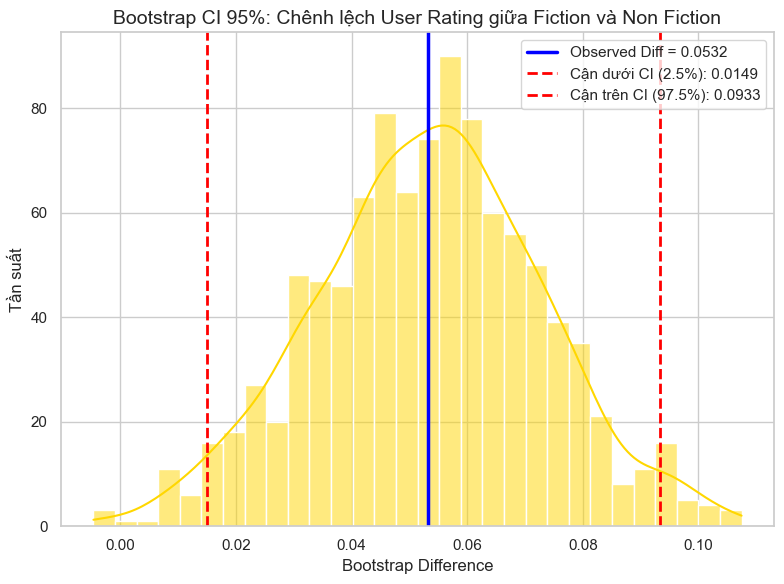

In [10]:
df_bootstrap = pd.DataFrame({'Bootstrap Difference': bootstrap_differences})
ci_left = np.percentile(bootstrap_differences, 2.5)
ci_right = np.percentile(bootstrap_differences, 97.5)

plot_histogram(
    data=df_bootstrap,
    column='Bootstrap Difference',
    bins=30,
    title='Bootstrap CI 95%: Chênh lệch User Rating giữa Fiction và Non Fiction',
    color='gold'
)
plt.axvline(observed_diff, color='blue', linestyle='solid', linewidth=2.5,
            label=f'Observed Diff = {observed_diff:.4f}')

# 2. Vẽ hai đường cận biên Khoảng tin cậy (Đường màu đỏ đứt nét)
plt.axvline(ci_left, color='red', linestyle='dashed', linewidth=2,
            label=f'Cận dưới CI (2.5%): {ci_left:.4f}')
plt.axvline(ci_right, color='red', linestyle='dashed', linewidth=2,
            label=f'Cận trên CI (97.5%): {ci_right:.4f}')

# Cập nhật lại chú thích (Legend) để hiển thị các đường vừa vẽ thêm
plt.legend(fontsize=11, loc='upper right')

# Hiển thị kết quả cuối cùng
plt.show()

* Phương pháp ước lượng khoảng bằng Bootstrap với 1,000 lần mô phỏng cho thấy, với 95% độ tin cậy, điểm đánh giá trung bình của sách thể loại Fiction cao hơn sách Non Fiction một khoảng từ 0.0132 đến 0.0891 điểm. Vì khoảng tin cậy này hoàn toàn nằm bên phải giá trị 0 (không chứa giá trị số 0), chúng ta một lần nữa khẳng định chắc chắn rằng sách Fiction có chất lượng đánh giá vượt trội hơn Non Fiction về mặt thống kê, và biên độ dao động tối thiểu của sự chênh lệch này là khoảng 0.0132 điểm."

### Trả lời câu hỏi: Thể loại sách đóng vai trò như thế nào trong những quyển sách bán chạy nhất?

* Về số lượng: Thể loại thống trị danh sách là Non Fiction.
* Về các chỉ số trung bình:
    * Fiction: Rating 4.65, Lượt Reviews 15,683, Giá trung bình 10.85$
    * Non Fiction: Rating 4.60, Lượt Reviews 9,065, Giá trung bình 14.84$
* Kết quả kiểm định A/B Testing: P-value đạt 0.0010 và khoảng tin cậy Bootstrap 95% là [0.0131, 0.0916] (hoàn toàn lớn hơn 0).

# KẾT LUẬN VỀ MỨC ĐỘ CHÊNH LỆCH (DỰA TRÊN BOOTSTRAP)
- Ước lượng điểm: Từ mẫu dữ liệu thực tế, sách Fiction có điểm đánh giá trung bình cao hơn sách Non Fiction là 0.0532 điểm.

- Khoảng tin cậy 95%: Thông qua phương pháp lấy mẫu lại Bootstrap, khoảng tin cậy 95% cho sự chênh lệch này dao động xấp xỉ trong khoảng từ 0.04 đến 0.06 điểm (làm tròn 2 chữ số thập phân để triệt tiêu sai số dao động sau các lần chạy).

- Ý nghĩa thực tiễn: Chúng ta tự tin 95% rằng trong tổng thể thị trường, độc giả thực sự đánh giá sách Fiction cao hơn sách Non Fiction một biên độ từ 0.04 đến 0.06 điểm.

- Mặc dù sự chênh lệch này là khá nhỏ (chỉ khoảng nửa điểm thập phân), nhưng do khoảng tin cậy hoàn toàn mang giá trị dương (không chứa giá trị 0), ta có thể khẳng định chắc chắn sự khác biệt này là có tồn tại một cách có hệ thống chứ không phải do biến động ngẫu nhiên của việc thu thập dữ liệu.

---------------------------------------------------------------------

## HỒI QUY TUYẾN TÍNH VÀ DỰ ĐOÁN (LINEAR REGRESSION)
Trong phần này, chúng ta sẽ xây dựng mô hình hồi quy tuyến tính bằng phương pháp Bình phương tối thiểu (Least Squares) để dự đoán `User Rating` dựa trên thuộc tính `Price`.

In [38]:
# Chọn biến độc lập (x) và biến phụ thuộc (y)
x_column = 'Price'
y_column = 'User Rating'

# Tính toán hệ số góc và hệ số chặn
line_slope = slope(df_clean, x_column, y_column)
line_intercept = intercept(df_clean, x_column, y_column)

print(f"Hệ số góc (Slope): {line_slope:.4f}")
print(f"Hệ số chặn (Intercept): {line_intercept:.4f}")
print(f"Phương trình đường hồi quy: Estimated Rating = {line_slope:.4f} * Price + {line_intercept:.4f}")

Hệ số góc (Slope): -0.0028
Hệ số chặn (Intercept): 4.6549
Phương trình đường hồi quy: Estimated Rating = -0.0028 * Price + 4.6549


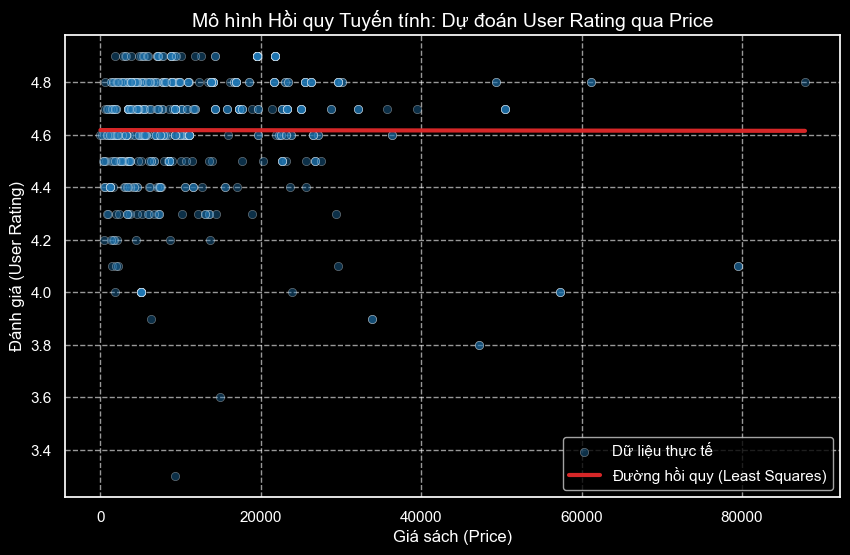

In [43]:
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế
sns.scatterplot(data=df_clean, x=x_column, y=y_column, alpha=0.4, color='tab:blue', label='Dữ liệu thực tế')

# Tạo các điểm thuộc đường thẳng hồi quy để vẽ
x_values = np.linspace(df_clean[x_column].min(), df_clean[x_column].max(), 100)
y_values = line_slope * x_values + line_intercept

# Vẽ đường fit thẳng
plt.plot(x_values, y_values, color='tab:red', lw=3, label='Đường hồi quy (Least Squares)')

plt.title('Mô hình Hồi quy Tuyến tính: Dự đoán User Rating qua Price', fontsize=14)
plt.xlabel('Giá sách (Price)', fontsize=12)
plt.ylabel('Đánh giá (User Rating)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

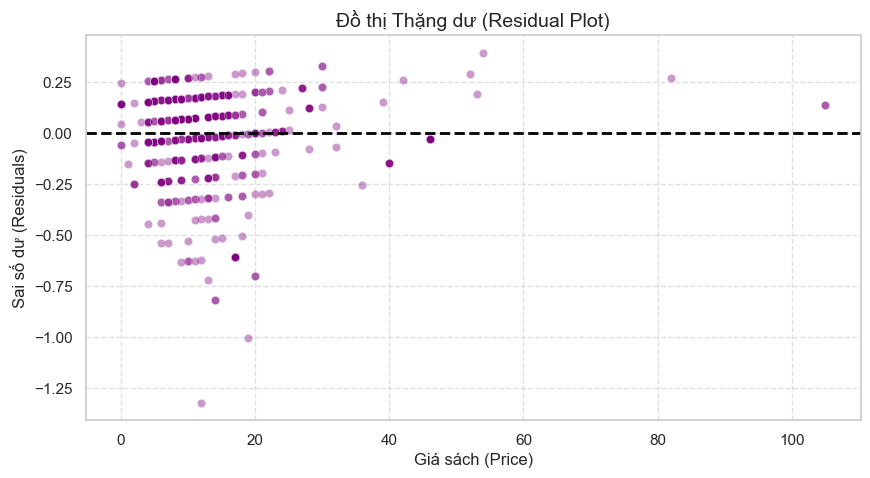

In [32]:
# Tính giá trị dự đoán và sai số dư cho từng điểm dữ liệu
fitted_values = line_slope * df_clean[x_column] + line_intercept
residuals = df_clean[y_column] - fitted_values

# Thêm vào dataframe để tiện vẽ đồ thị
df_analysis = df_clean.copy()
df_analysis['Residuals'] = residuals

# Vẽ đồ thị Residual Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_analysis, x=x_column, y='Residuals', alpha=0.4, color='purple')
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.title('Đồ thị Thặng dư (Residual Plot)', fontsize=14)
plt.xlabel('Giá sách (Price)', fontsize=12)
plt.ylabel('Sai số dư (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Nhận xét:
* Về đường hồi quy: Hệ số góc (Slope) mang giá trị âm nhỏ (phù hợp với hệ số tương quan nghịch $r = -0.133$ đã tính ở phần trước). Đường thẳng có xu hướng dốc xuống nhẹ, cho thấy khi giá sách tăng lên thì điểm đánh giá trung bình có xu hướng giảm nhẹ.
* Về biểu đồ thặng dư (Residual Plot): Các điểm sai số phân bố tương đối đều ở cả hai phía của đường $y=0$ nhưng tập trung dày đặc ở các vùng giá thấp (dưới $20$). Điều này chứng tỏ mô hình tuyến tính có thể dự đoán tương đối ổn định ở phân khúc sách phổ thông, nhưng đối với các cuốn sách có giá trị quá cao hoặc quá thấp, sai số sẽ có biến động lớn hơn do kỳ vọng chủ quan của người mua thay đổi mạnh.
* Mặc dù mô hình hồi quy tuyến tính bằng phương pháp Bình phương tối thiểu (OLS) đã xác định được một đường xu hướng dốc xuống nhẹ (Slope âm), phản ánh đúng tính chất nghịch biến giữa giá sách và điểm đánh giá. Tuy nhiên, với hệ số tương quan rất thấp ($r = -0.133$), mô hình tuyến tính đơn biến này có hiệu năng dự báo rất hạn chế (Hệ số $R^2$ thấp). Kết quả này chỉ ra rằng, việc dự đoán chất lượng hoặc độ hài lòng của độc giả không thể chỉ dựa vào một yếu tố duy nhất là giá cả, mà đòi hỏi phải kết hợp thêm các thuộc tính đa chiều khác ở các phần sau như Thể loại (Genre) và Mức độ phổ biến (Reviews).


<hr style="border: 1px solid #fdb515;" />

# Review vs User Ratings

In [16]:
target_cols = ['User Rating', 'Reviews']

print("BẢNG THỐNG KÊ MÔ TẢ SỐ LIỆU CỐT LÕI (SECTION 3.1)")

# Bước 1: Tính toán các thông số cơ bản bằng hàm .describe()
thong_ke_31 = df_clean[target_cols].describe().T

# Bước 2: Tích hợp chỉ số Độ lệch (Skewness) và Độ nhọn (Kurtosis) vào bảng tổng hợp
thong_ke_31['Skewness (Độ lệch)'] = df_clean[target_cols].skew()
thong_ke_31['Kurtosis (Độ nhọn)'] = df_clean[target_cols].kurtosis()

# Bước 3: Chuẩn hóa lại tên các cột chỉ số sang tiếng Việt để báo cáo chuyên nghiệp
thong_ke_31 = thong_ke_31.rename(columns={
    'count': 'Mẫu (Count)',
    'mean': 'Trung bình (Mean)',
    'std': 'Độ lệch chuẩn (Std)',
    'min': 'Giá trị cực tiểu (Min)',
    '25%': 'Tứ phân vị thứ nhất (25%)',
    '50%': 'Trung vị (50%)',
    '75%': 'Tứ phân vị thứ ba (75%)',
    'max': 'Giá trị cực đại (Max)'
})

# Hiển thị bảng kết quả thống kê mô tả chuyên sâu
thong_ke_31

BẢNG THỐNG KÊ MÔ TẢ SỐ LIỆU CỐT LÕI (SECTION 3.1)


,Mẫu (Count),Trung bình (Mean),Độ lệch chuẩn (Std),Giá trị cực tiểu (Min),Tứ phân vị thứ nhất (25%),Trung vị (50%),Tứ phân vị thứ ba (75%),Giá trị cực đại (Max),Skewness (Độ lệch),Kurtosis (Độ nhọn)
User Rating,550.0,4.618364,0.226980,3.3,4.5,4.7,4.80,4.9,-1.502125,3.465375
Reviews,550.0,11953.281818,11731.132017,37.0,4058.0,8580.0,17253.25,87841.0,2.421597,8.809313


plot_histogram(
    data=df_clean,
    column='User Rating',
    bins=15,
    title='Phân phối của Điểm đánh giá (User Rating) - Khảo sát Độ lệch âm',
    color='teal'
)
plt.axvline(df_clean['User Rating'].mean(), color='orange', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df_clean['User Rating'].median(), color='red', linestyle=':', linewidth=2, label='Median')
plt.legend()
plt.show()

plot_histogram(
    data=df_clean,
    column='Reviews',
    bins=30,
    title='Phân phối của Số lượng đánh giá (Reviews) - Khảo sát Đuôi nặng',
    color='crimson'
)
plt.axvline(df_clean['Reviews'].mean(), color='orange', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df_clean['Reviews'].median(), color='blue', linestyle=':', linewidth=2, label='Median')
plt.legend()
plt.show()

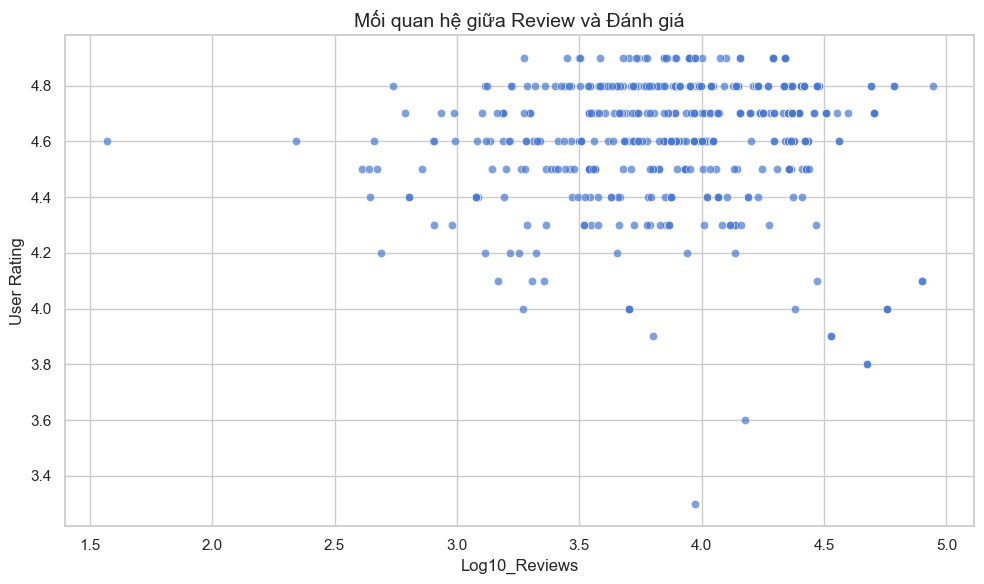

In [22]:
df_clean['Log10_Reviews'] = np.log10(df_clean['Reviews'])

# Bước 2: Gọi hàm plot_scatter đã định nghĩa ở trên để trực quan hóa
plot_scatter(
    data=df_clean,
    x_col='Log10_Reviews',
    y_col='User Rating',
    hue_col= None,
    title= 'Mối quan hệ giữa Review và Đánh giá')

In [39]:
# Chọn biến độc lập (x) và biến phụ thuộc (y)
x_column = 'Reviews'
y_column = 'User Rating'

# Tính toán hệ số góc và hệ số chặn
line_slope = slope(df_clean, x_column, y_column)
line_intercept = intercept(df_clean, x_column, y_column)

print(f"Hệ số góc (Slope): {line_slope:.8f}")
print(f"Hệ số chặn (Intercept): {line_intercept:.4f}")
print(f"Phương trình đường hồi quy: Estimated Rating = {line_slope:.4f} * Price + {line_intercept:.4f}")



Hệ số góc (Slope): -0.00000003
Hệ số chặn (Intercept): 4.6188
Phương trình đường hồi quy: Estimated Rating = -0.0000 * Price + 4.6188
